In [ ]:
# 11 — Remaining Targets

Closes the three targets from the project brief that have not yet been
analysed:

- Target 8: plus-one shot success. The plus-one is shot 3, the server's first
  shot after the return. It is often described as the most important shot in
  modern tennis.
- Targets 2 and 3: the binary success target and the engineered aggressiveness
  index, both built in notebook 05 but not yet modelled.
- Serve placement, analysed counterfactually rather than descriptively.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import pickle
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (classification_report, accuracy_score,
                             f1_score, roc_auc_score)
from xgboost import XGBClassifier

sns.set_style("whitegrid")

CWD = Path.cwd()
PROJECT_ROOT = CWD if (CWD / "data").exists() else CWD.parent
PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "figures"

data = pd.read_parquet(PROCESSED / "model_data.parquet")
shots = pd.read_parquet(PROCESSED / "shots_eda.parquet")
points = pd.read_parquet(PROCESSED / "points_eda.parquet")

CATEGORICAL = ["shot_type", "direction", "direction_pattern", "to_opponent_wing",
               "prev_shot_type", "prev_direction", "prev_depth",
               "serve_direction", "pressure_context", "Surface", "gender"]
NUMERIC = ["shot_number", "is_approach", "prev_approach",
           "is_serving", "is_second_serve"]

for col in CATEGORICAL:
    data[col] = data[col].fillna("none").astype(str)
for col in NUMERIC:
    data[col] = data[col].fillna(0).astype(float)

CLASSES = ["in_play", "unforced_error", "forced_error", "winner"]
print("Data:", data.shape)

Data: (5207197, 21)


In [2]:
# Shot 1 is the serve, shot 2 the return, shot 3 the plus-one. It is the
# server's first chance to attack from a ball they have partly set up
# themselves, which is why coaches treat it as decisive.
plus_one = shots[shots["shot_number"] == 3].copy()
print(f"Plus-one shots: {len(plus_one):,}")
print()
print(plus_one["shot_outcome"].value_counts(normalize=True).round(3))

Plus-one shots: 955,283

shot_outcome
in_play           0.758
unforced_error    0.104
winner            0.094
forced_error      0.045
Name: proportion, dtype: float64


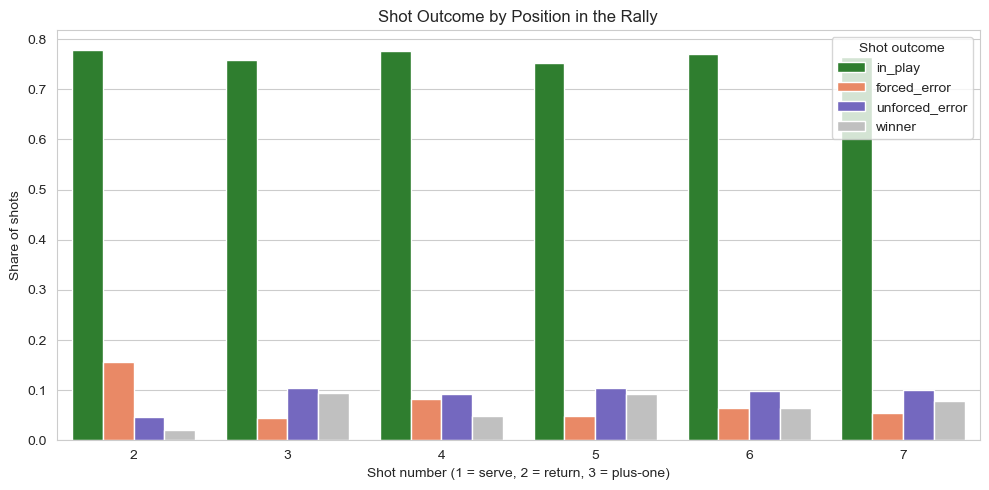

In [3]:
# Is the plus-one really special, or does it just look that way because it
# comes early in the rally? Comparing it with shots 4, 5 and 6 answers this.
comparison = shots[shots["shot_number"].between(2, 7)].copy()

outcome_by_shot = (comparison.groupby("shot_number", observed=True)["shot_outcome"]
                   .value_counts(normalize=True)
                   .rename("share").reset_index())

plt.figure(figsize=(10, 5))
sns.barplot(data=outcome_by_shot, x="shot_number", y="share", hue="shot_outcome",
            palette=["forestgreen", "coral", "slateblue", "silver"])
plt.title("Shot Outcome by Position in the Rally")
plt.xlabel("Shot number (1 = serve, 2 = return, 3 = plus-one)")
plt.ylabel("Share of shots")
plt.legend(title="Shot outcome")
plt.tight_layout()
plt.savefig(FIGURES / "plus_one_by_shot_number.png", dpi=150)
plt.show()

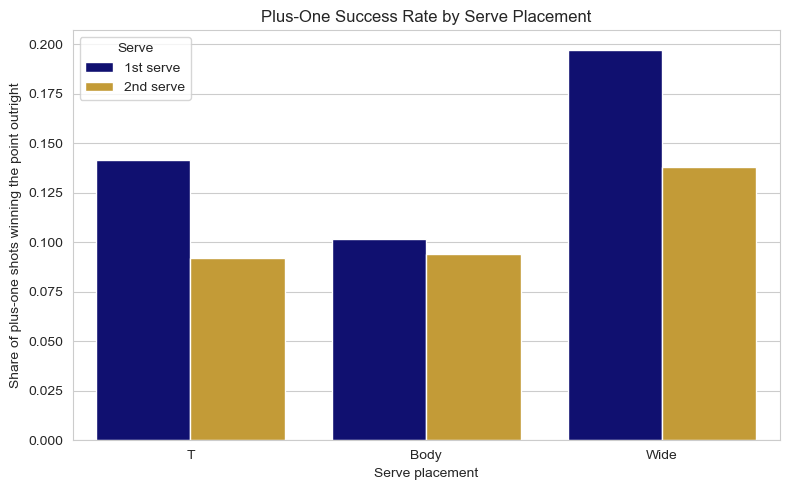

serve_direction  is_second_serve  success_rate serve_number
           Body            False        0.1019    1st serve
           Body             True        0.0940    2nd serve
              T            False        0.1417    1st serve
              T             True        0.0919    2nd serve
           Wide            False        0.1971    1st serve
           Wide             True        0.1378    2nd serve


In [4]:
# Does where the serve landed change how well the plus-one goes? This links
# Target 7 and Target 8: the serve is meant to set up the shot that follows.
plus_one = plus_one.merge(
    points[["match_id", "Pt", "serve_direction", "is_second_serve", "Surface"]],
    on=["match_id", "Pt"], how="left")

plus_one["is_successful"] = plus_one["shot_outcome"].isin(
    ["winner", "forced_error"])

serve_effect = (plus_one.dropna(subset=["serve_direction"])
                .groupby(["serve_direction", "is_second_serve"], observed=True)
                ["is_successful"].mean().rename("success_rate").reset_index())
serve_effect["serve_number"] = np.where(serve_effect["is_second_serve"],
                                        "2nd serve", "1st serve")

plt.figure(figsize=(8, 5))
sns.barplot(data=serve_effect, x="serve_direction", y="success_rate",
            hue="serve_number", palette=["navy", "goldenrod"],
            order=["T", "Body", "Wide"])
plt.title("Plus-One Success Rate by Serve Placement")
plt.xlabel("Serve placement")
plt.ylabel("Share of plus-one shots winning the point outright")
plt.legend(title="Serve")
plt.tight_layout()
plt.savefig(FIGURES / "plus_one_by_serve_placement.png", dpi=150)
plt.show()

print(serve_effect.round(4).to_string(index=False))

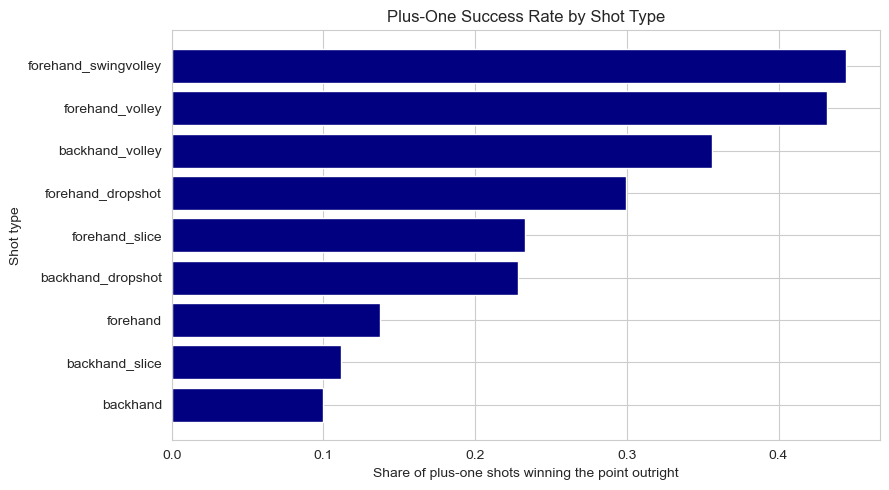

                           n  success
shot_type                            
forehand_swingvolley    5060   0.4447
forehand_volley         9907   0.4321
backhand_volley        10511   0.3559
forehand_dropshot      10660   0.2992
forehand_slice         15701   0.2327
backhand_dropshot       9709   0.2284
forehand              536695   0.1371
backhand_slice         33410   0.1118
backhand              313434   0.0994


In [5]:
# The classic tactic is to serve wide and then attack the open court with a
# forehand. This checks whether the forehand plus-one really outperforms.
wing = (plus_one.groupby("shot_type", observed=True)
        .agg(n=("is_successful", "size"), success=("is_successful", "mean"))
        .query("n >= 5000").sort_values("success", ascending=False))

plt.figure(figsize=(9, 5))
plt.barh(wing.index[::-1], wing["success"][::-1], color="navy")
plt.title("Plus-One Success Rate by Shot Type")
plt.xlabel("Share of plus-one shots winning the point outright")
plt.ylabel("Shot type")
plt.tight_layout()
plt.savefig(FIGURES / "plus_one_by_shot_type.png", dpi=150)
plt.show()

print(wing.round(4).to_string())

In [6]:
# This target answers a narrower question than the four-class model: GIVEN
# that a shot ended the point, did it end it well? Only decisive shots are
# used, so the majority class problem largely disappears.
decisive = data[data["target_binary"].notna()].copy()
decisive["y"] = (decisive["target_binary"] == "success").astype(int)

print(f"Decisive shots: {len(decisive):,}")
print(decisive["target_binary"].value_counts(normalize=True).round(3))

matches = decisive["match_id"].unique()
rng = np.random.default_rng(42)
rng.shuffle(matches)
test_matches = set(matches[:int(len(matches) * 0.2)])

train = decisive[~decisive["match_id"].isin(test_matches)].sample(
    300_000, random_state=42)
test = decisive[decisive["match_id"].isin(test_matches)]

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
encoder.fit(train[CATEGORICAL])

def build(df):
    return sp.hstack([encoder.transform(df[CATEGORICAL]),
                      sp.csr_matrix(df[NUMERIC].values)]).tocsr()

binary_model = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                             tree_method="hist", n_jobs=-1, random_state=42)
binary_model.fit(build(train), train["y"].values)

predicted = binary_model.predict(build(test))
probabilities = binary_model.predict_proba(build(test))[:, 1]

print(f"\nAccuracy: {accuracy_score(test['y'], predicted):.4f}")
print(f"ROC-AUC:  {roc_auc_score(test['y'], probabilities):.4f}")
print(f"Baseline: {max(test['y'].mean(), 1 - test['y'].mean()):.4f}")
print()
print(classification_report(test["y"], predicted,
                            target_names=["failure", "success"]))

Decisive shots: 1,155,642
target_binary
success    0.608
failure    0.392
Name: proportion, dtype: float64

Accuracy: 0.7243
ROC-AUC:  0.8054
Baseline: 0.6085

              precision    recall  f1-score   support

     failure       0.64      0.69      0.66     89266
     success       0.79      0.75      0.77    138750

    accuracy                           0.72    228016
   macro avg       0.71      0.72      0.71    228016
weighted avg       0.73      0.72      0.73    228016



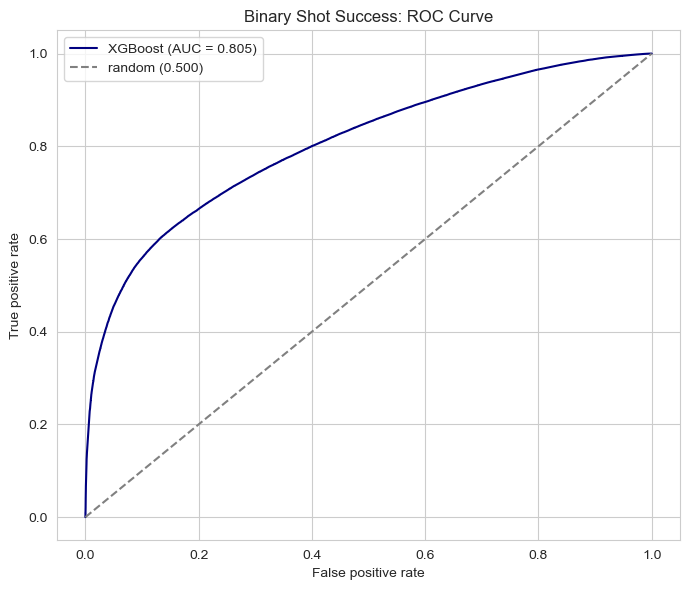

In [7]:
from sklearn.metrics import roc_curve

# ROC-AUC is the right summary here because the two classes are reasonably
# balanced and the model outputs a probability rather than a hard label.
fpr, tpr, _ = roc_curve(test["y"], probabilities)
auc = roc_auc_score(test["y"], probabilities)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="navy", label=f"XGBoost (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="random (0.500)")
plt.title("Binary Shot Success: ROC Curve")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES / "binary_target_roc.png", dpi=150)
plt.show()

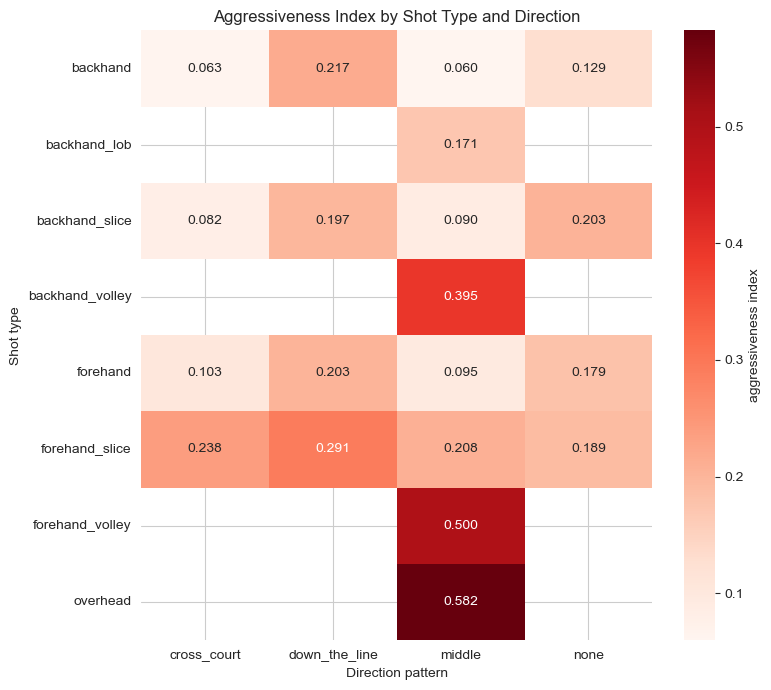

direction_pattern  cross_court  down_the_line  middle   none
shot_type                                                   
backhand                 0.063          0.217   0.060  0.129
backhand_lob               NaN            NaN   0.171    NaN
backhand_slice           0.082          0.197   0.090  0.203
backhand_volley            NaN            NaN   0.395    NaN
forehand                 0.103          0.203   0.095  0.179
forehand_slice           0.238          0.291   0.208  0.189
forehand_volley            NaN            NaN   0.500    NaN
overhead                   NaN            NaN   0.582    NaN


In [8]:
# The aggressiveness index is ENGINEERED, not observed: a shot scores 1 if it
# won the point outright or forced an error from the opponent. It is a
# summary of outcome, so it must never be used as a model feature. Here it is
# used descriptively, to profile how aggressive different choices are.
aggression = (data.groupby(["shot_type", "direction_pattern"], observed=True)
              .agg(n=("aggressiveness", "size"),
                   aggression=("aggressiveness", "mean"))
              .query("n >= 20000").reset_index())

pivot = aggression.pivot(index="shot_type", columns="direction_pattern",
                         values="aggression")

plt.figure(figsize=(8, 7))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="Reds",
            cbar_kws={"label": "aggressiveness index"})
plt.title("Aggressiveness Index by Shot Type and Direction")
plt.xlabel("Direction pattern")
plt.ylabel("Shot type")
plt.tight_layout()
plt.savefig(FIGURES / "aggressiveness_heatmap.png", dpi=150)
plt.show()

print(pivot.round(3).to_string())

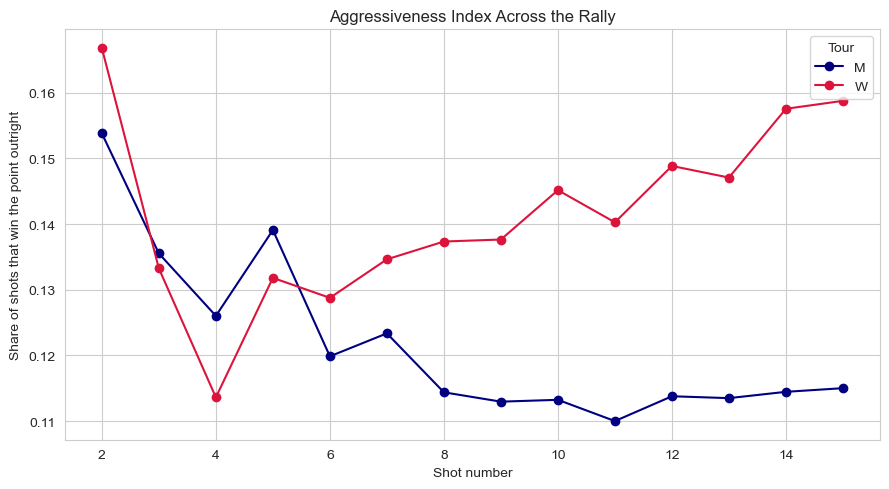

In [9]:
# Does play become more or less aggressive as a rally goes on?
by_position = (data[data["shot_number"] <= 15]
               .groupby(["shot_number", "gender"], observed=True)
               ["aggressiveness"].mean().rename("aggression").reset_index())

plt.figure(figsize=(9, 5))
for tour, colour in [("M", "navy"), ("W", "crimson")]:
    subset = by_position[by_position["gender"] == tour]
    plt.plot(subset["shot_number"], subset["aggression"],
             marker="o", color=colour, label=tour)

plt.title("Aggressiveness Index Across the Rally")
plt.xlabel("Shot number")
plt.ylabel("Share of shots that win the point outright")
plt.legend(title="Tour")
plt.tight_layout()
plt.savefig(FIGURES / "aggressiveness_by_rally_position.png", dpi=150)
plt.show()

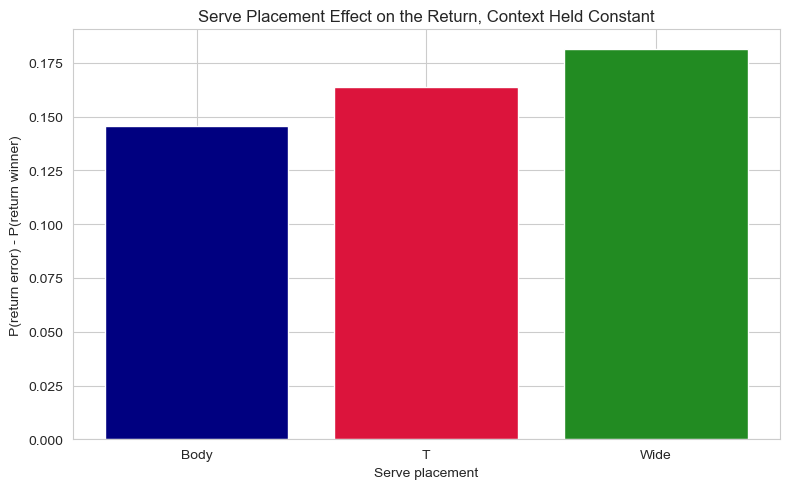

outcome  forced_error  in_play  unforced_error  winner  server_advantage
serve                                                                   
Body           0.1190   0.8124          0.0477  0.0210            0.1456
T              0.1380   0.8008          0.0435  0.0177            0.1638
Wide           0.1559   0.7702          0.0498  0.0242            0.1815


In [10]:
# Section 5.4 showed body serves winning fewer points, but that is confounded:
# players choose the body serve in particular situations. The counterfactual
# asks what would happen if the SAME points had been served elsewhere.
with open(PROCESSED / "model_artifacts.pkl", "rb") as f:
    artifacts = pickle.load(f)

cf_encoder = artifacts["encoder"]
cf_model = artifacts["xgb"]

SERVES = ["T", "Body", "Wide"]

# The serve sets up the return, so shot 2 is where its effect shows.
returns = data[data["shot_number"] == 2].sample(50_000, random_state=42)

rows = []
for placement in SERVES:
    scenario = returns.copy()
    scenario["serve_direction"] = placement

    matrix = sp.hstack([cf_encoder.transform(scenario[CATEGORICAL]),
                        sp.csr_matrix(scenario[NUMERIC].values)]).tocsr()
    probabilities = cf_model.predict_proba(matrix).mean(axis=0)

    for i, class_name in enumerate(CLASSES):
        rows.append({"serve": placement, "outcome": class_name,
                     "probability": probabilities[i]})

serve_cf = pd.DataFrame(rows)
serve_table = serve_cf.pivot(index="serve", columns="outcome",
                             values="probability")

# From the SERVER's point of view: a returner error is good news.
serve_table["server_advantage"] = (serve_table["unforced_error"]
                                   + serve_table["forced_error"]
                                   - serve_table["winner"])

plt.figure(figsize=(8, 5))
plt.bar(serve_table.index, serve_table["server_advantage"],
        color=["navy", "crimson", "forestgreen"])
plt.title("Serve Placement Effect on the Return, Context Held Constant")
plt.xlabel("Serve placement")
plt.ylabel("P(return error) - P(return winner)")
plt.tight_layout()
plt.savefig(FIGURES / "counterfactual_serve.png", dpi=150)
plt.show()

print(serve_table.round(4).to_string())

In [11]:
# Side by side with the raw figures from section 5.4, to see how much of the
# body serve's apparent weakness survives once context is controlled.
print("Raw server win rate, 1st serve (section 5.4):")
print("  T     0.711")
print("  Body  0.595")
print("  Wide  0.707")
print()
print("Counterfactual advantage on the return:")
print(serve_table["server_advantage"].round(4).to_string())

serve_table.to_csv(FIGURES / "counterfactual_serve.csv")

Raw server win rate, 1st serve (section 5.4):
  T     0.711
  Body  0.595
  Wide  0.707

Counterfactual advantage on the return:
serve
Body    0.1456
T       0.1638
Wide    0.1815
